# Machine Learning Algorithm Implementation

## Introduction

This notebook house the implementation of the machine learning models deployed using the preprocessed data from notebooks one and two. There will be two models deployed wihtin the notebook. The first, KMeans followed by DBSCAN. 

## 0.1 - Imports
The code block below represents where all imports for the noteboook are imported and initilised. 

In [1]:
# Import Library
import pandas as pd
import numpy as np

# Sklearn Imports:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# Data Display Imports
import matplotlib.pyplot as plt

## 0.2 Import Datasets
This code block represents where all the datasets that will be worked on throughout this notebook are imported and initilised. 'customer_features' is copied in order to preserve the original data. 

In [2]:
# Import the scaled dataset
customer_features_scaled = pd.read_csv('../0_Data/processed_data/customer_features_scaled.csv')
customer_features = pd.read_csv('../0_Data/processed_data/customer_features.csv')

# Create a copy of the dataset we will be working on: 
scaled_df = customer_features_scaled.copy()

# Establish a random state value to enable reproducable results
random_state = 42

## 1.0 Pre-Pipeline Steps
At this point scaling and preprocessing has been completely finished. However there are still a few steps we need to confirm before initlising the pipeline. The first is removing customer_id from the dataset. This is done because customer_id does not provide any benifit for the models in terms of unveiling consumer behaviour and secondly, it is the only column that did not have StandardScalar applied to it - as we did not want to change the actual customer_id's.

In [3]:
# pull customer_id into its own dataset; 
customer_ids = scaled_df['customer_id']

# Drop customer_id from the working dataset: 
scaled_df = scaled_df.drop(columns=['customer_id'])

# Implement a function that checks if customer_id was successfully removed.
def customer_features_removal(df):
    if scaled_df.columns.all() == 'customer_id':
        print("'customer_id' still present")
    else: print("'customer_id' successfully removed")

# Call the customer_features_removal function using scaled_df. 
customer_features_removal(scaled_df)

'customer_id' successfully removed


## 2.0 - Machine Learning Pipeline Implementation
This chapter marks the begining of the machine learning model implementations. Starting with KMeans. 

### 2.1 - KMeans Algorithm
The first algorithm to be used is KMeans. KMeans is a common clustering algorithm and appropriate for a segmentation taks. This algoirthm splits data into a specified number of groups defined as 'k'. Each group has a centriod and points are assinged to specific groups depending on the distance each point is to a centriod. The reason for using this algorithm is to assess whether customers can be groups into distinc behavorial patterns/ types based on thier transactional profiles. The question KMeans aims to answer is can grouping customers in this manner reveal identifable differences; for example a group with high cancellation rates or high spend but low visits. 

### 2.2 - Determining K
KMeans is a clustering algorithim that is distance based. The idea behind its implementation within this context is to uncover clusters within the data. This is powerful as patterns that arent necessirily present then looking at raw data are uncovered during visual segments.

Before implementing the algorithm, the value of k needs to be determined. In this context K represents how many different groups or segments the algorithm will produce. It is important to find a suitable value for 'k' due to multiple reasons: 

- **If K is to low**: If the value of k is too low, unique and distinct bevahours can be missed where different groups are combined with eachother - removing the point of the algorithm entirely. For example, if k was too low, multiple different groups will be forced together in order to adhere to the algorithms demands. In this case the meaningful relationships we are trying to capture will be missed. 

- **k to high**: On the other hand if k is too high clusters fracture into indisgusiable segemnts that do not represent groupings of behaviour. An example of this is if k = 100 and was deployed on a dataset with 100 observations, there is a likely chance that each observations (or customer in this context) would be grouped on its own. This would not produce any meaningful insights. 

- **Getting k correct**: Getting k correct resembles the point where clusters represent meaningful and insightful behvioural patterns, which can be usd to uncover patterns within the data that would otherwise been missed. This is why finding the most suitable value of 'k' is important. 

**'k' Value Indentification Methodology:**
The first method that can be used to identify the most effective value of 'k' is the elbow method. This methods uses a metric known as 'inertia' as a way of measuring how closely plotted points are from their assinged cluster and is calulated by summing the square of the distances each point is from its centroid (cluster), this final summed value is what is known as the inertia. If inertia is low, it means that on average each points is situated closed to its own centriod meaning each point is tight within its own group and each point is behavorially similar to the other points in its group. If inertia is high, there is an indication that points are not tight but rather they are scattered far from their centroid. In this case groups are loose and contain multiple customers with different beahvioral traits that have been lumped together. This relates to choosing a value of 'k' as the more clusters that are requested, the smaller each group will be and naturally it means that each point will be closer to a more specific centroid. The key with this test is not identifying the lowest point but where the elbow is situated (displayed visually within a graph). The elbow represents the point at which increasing values of k stops providing value and start diluting clusters. Using the elbow method should result in a plot that decreases sharply at first and then levels off. It is at this point of the leveling off (the elbow) where the value of 'k' is the best choice for the data. 

Sometimes, the result of the elbow method does not produce a clear and distinct point of leveling off. This is why it is useful to deploy a second method of identifying the most suitable value of 'k' - silhouete score. 

Silhouette score is reponsible for measuring the quality of the clusters that are created. The silhouette score measures two things. The first is the how close each point is to the other points within its own cluster as well as how far away it is from points in other clusters. The idea is, if a point sits close to other points within its own cluster and far away from other clusters, it is given a high score (closer to +1). However, in the opposite case, if a point is sitting closer to another cluster, the score is lower (closer to -1). Scores are issued in the range of -1 to 1. By combining the average silhouette score for each point the result should indicate how well defined each cluster is - value of k with the highest silhouette score is usually the a solid indicator of the best value of 'k'.

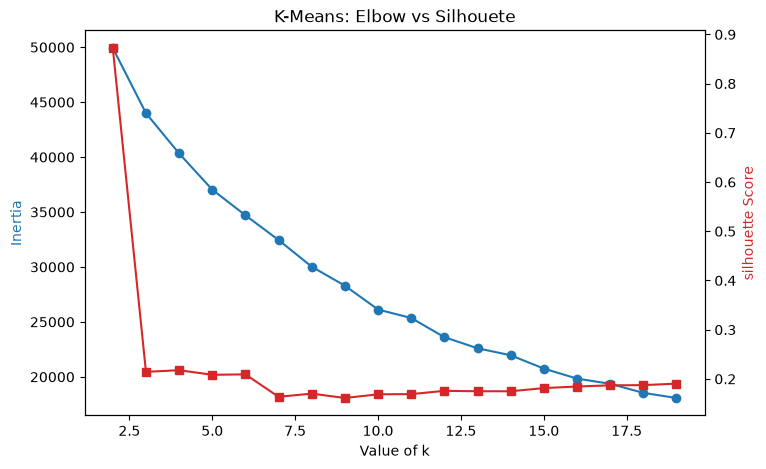

In [4]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 20 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    # random_state is a fixed value to ensure reproduceable results. 
    km = KMeans(n_clusters = k, n_init = 10)
    # Fit the algorithm on the scaled dataset:
    labels = km.fit_predict(scaled_df)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(scaled_df, labels))

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouette_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

**Plot Results**

The plot above shows the results for both methods that were carried out. Inertia displays no slowing in the rate of decrease on inertia value, every iteration of 'k' improves inertia by roughly the same amount therefore giving no clear indication of a suitable value of 'k'.

Silhouette on the other hand, peaks at k = 2. A silhouette score of 0.9 for k = 2 indicates that there is a clear divide in the data that may be causing dilution within other features. A likely suspect for this is the wholesale customers that were kept during preprocessing. A low sihouette score, can be attributed to mutiple points that are pulled apart from others. Whilst these results are not necessirily wrong, theyre are unexpected and could indicate that some points may be influencing with both of these metrics.A likely cause of this is the wholesale transactions that were left in during preprocessing and should will be investigated for confirmation. 

To start building a picture of what is effecting the results, a describe() filtering to display only min and max values will be displayed below. This aims to provide an insight into range between the smallest and largest values in each feature. 

In [5]:
# Display the Min and Max results of the scaled dataset:
scaled_df.describe().loc[['min', 'max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-2.036680,-48.946912,-0.410267,-0.326596,-0.676258,-0.690148,-2.483556,-1.369769,-1.426411,-0.647945
max,41.527424,22.346992,31.460162,42.868300,4.668382,21.270907,3.292813,1.853239,10.654583,1.543341


**Min & Max Descibe Evaluation**

As seen in the preprocessing pipeline, standardscalar was implemented on the data. When used standardscalar converts features and their values into standard deviations from the mean. This is helpful in ensuring every feature contributes equally in the case of features being on drastically different scales (for example total_spend being in the thousands and unique products being in the tens) as this would cause total_spend to dominate the distance calculations. Displaying the Min and Max values for each feature above confirms that there are values that sit drastically outside of the mean like total_spend having min and max values of -2.04 and 41.52 standard deviations from the mean and is evidence that extreme outliers can be distorting clusters. 

Whilst wholesale transactions represent a genuine business segment, their influence on other clusters is unhelpful. Before removing wholesale customers, it is necessary to identify a point at which treansactions stop behaving like typcial retail transactions and more like wholesale ones. To begin, a visual inspection on the sorted distribution of total_spend will be carried out. 


Distribution of total spend:


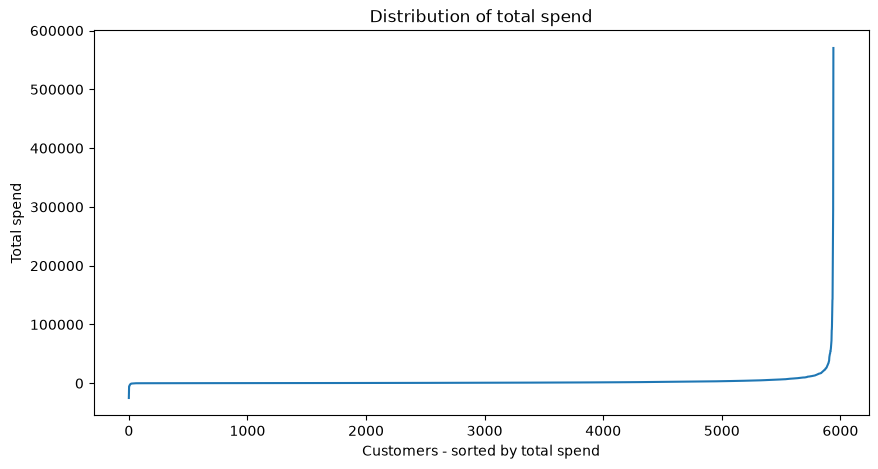

Tail Inspection of last 442 customers:


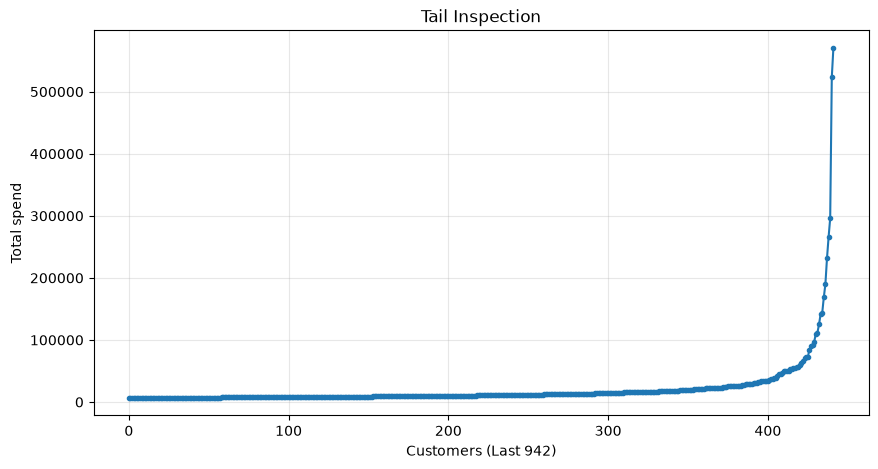

In [6]:
# Create a variable using the unscaled customer_features - grouped on 'customer_id' and 'total_spend':
transaction_spend_split = customer_features.groupby('customer_id')['total_spend'].sum().sort_values()

# Initilise a plot to display the results:
# Set figure size:
plt.figure(figsize = (10, 5))
# Plot the values stored in the variable initilised above:
plt.plot(transaction_spend_split.values)
# X-label: Where each customer sits on an ordered total_spend list:
plt.xlabel('Customers - sorted by total spend')
# Y-label: Total Spend amount:
plt.ylabel('Total spend')
# PLot title:
plt.title('Distribution of total spend')
# Display the plot:
print("Distribution of total spend:")
plt.show()

# Initilise another variable focusing on the top 442 Customers:
tail_inspection = transaction_spend_split[5500 : 5942].reset_index(drop = True)

# Set figure size:
plt.figure(figsize = (10, 5))
#
plt.plot(tail_inspection.index, tail_inspection.values, marker = 'o', markersize = 3)
#
plt.xlabel('Customers (Last 942)')
#
plt.ylabel('Total spend')
# Set plot title
plt.title('Tail Inspection')
#
plt.grid(True, alpha = 0.3)
# Display the plot
print("Tail Inspection of last 442 customers:")
plt.show()



**Plot Evaluation**

The plot above is highly conclusive. As seen the vast majority of customers have a similar total spend of much less than £100,000 and there small amount of customers with extraordinary total_spend values. Inspecting the 'tail inspection' plot, the point at which total_spend begins to increase is the 400th customer mark. The extremes shown in both plots conclude that it is reasonable to remove any wholesale customers from the dataset. The plot indicates that total_spend starts increasing within the last  100-120 customers. To ensure the validity of the data 

Whilst the plot provides a useful visual indication, there is not enough information to establish a definative split between retail and wholesale consumers. Removing customers based on total spend alone may run the risk of removing valuable high spending retail customers (for example a loyal repeat customer with high spend and a high number of visits). 

To remove this risk, 'total_item_count' will also be used to try to identify wholesale transactions with more accuracy - it is rare that wholesale transacitons will have low spend and quantity amounts, as such is the nature of wholesale transacitions, as bulk purchases are intrinsic within their nature. 

To formalise this definition, a threshold is defined using the 95th percentiles combined on total_spend and total_item_count. This means that a customer will only be classified as a wholesale customer if they exceed both percentile thresholds. 

In [7]:
# Initilise a variable representing the 95th percentile value for spend and qty
# Total Spend
spend_cutoff = customer_features['total_spend'].quantile(0.95)
# Total Item Count
quantity_cutoff = customer_features['total_item_count'].quantile(0.95)

# Establish a boolean mask marking a customer as True for 95th percentile values. 
wholesale_marker = ((customer_features['total_spend'] >= spend_cutoff) & 
                    (customer_features['total_item_count'] >= quantity_cutoff))

# Remove all instances of customers who are above the threshold: 
# Store the observations 
retail_features = customer_features[~wholesale_marker]

# Print values: 
print("")
print(f"Total Spend Cutoff Value: £{spend_cutoff:.2f}")
print(f"Quantity Cutoff Value: {quantity_cutoff:.2f}")
print(f"Total Customer Profiles Removed: {5942 - len(retail_features)}")
print(f"Remaining Retail Cusotmers: {len(retail_features)}")



Total Spend Cutoff Value: £8746.50
Quantity Cutoff Value: 5180.85
Total Customer Profiles Removed: 234
Remaining Retail Cusotmers: 5708


In [8]:
# Re-initilise Feature_cols variable, without customer_id: 
feature_cols = ['total_spend', 'atv', 'total_visits', 'total_item_count',
                'cancellation_rate', 'unique_products', 'time_of_day', 'day_of_week',
                'discount_rate', 'loyalty_member']

# Re-initilise StandardScaler:
scaler = StandardScaler()

# Re-run StandardScalar on the retail dataset: 
retail_scaled = scaler.fit_transform(retail_features[feature_cols])

Now that wholesale customers will have been removed from the dataset and StandardScalar has been re-deployed. A Min and Max describe will be ran again comparing the results with the original test and to confirm if outlier results were removed successfully. 

In [9]:
# Display the Min and Max results of the scaled dataset:
pd.DataFrame(retail_scaled, columns= feature_cols).describe().loc[['min', 'max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-13.394317,-56.511128,-0.691893,-1.641791,-0.657119,-0.824025,-2.479732,-1.369313,-1.398501,-0.646090
max,7.422657,10.269374,13.995024,12.561533,4.630330,9.651345,3.270637,1.838803,10.456100,1.547772


When comparing with original min and max describe output, we can see that the high-end maximums have drastically improved (total_spend dropped from a max of 41.5 to 7.4 and total_item_count is down from 31.5 to 14.0). This is clear evidence that removing the wholesale transacitons has improved the spread of values. 

It is worth noting however, that ATV min and max values worsened specifically in the negative direction:

- Min: -48.94 -> -56.51
- Max: 22.34 -> 10.2

Before investigating, elbow and silhouette tests will be ran again, assessing the differences and determining whether extreme values are still affecting the data. 

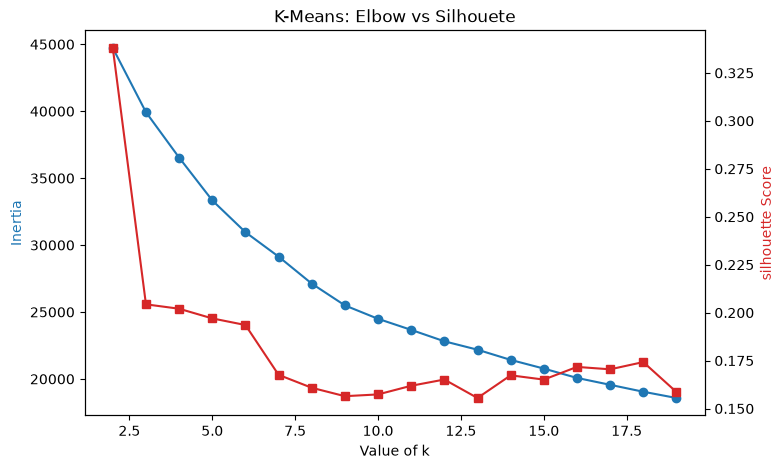

,k,inertia,silhouette
0,2,44723.208260,0.337985
1,3,39927.471434,0.204341
2,4,36537.160172,0.202051
3,5,33339.661102,0.197010
4,6,30965.335056,0.193561
5,7,29137.705308,0.167592
6,8,27122.295474,0.160844
7,9,25493.569379,0.156456
8,10,24491.362364,0.157379
9,11,23664.680212,0.161891


In [10]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 20 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    km = KMeans(n_clusters = k, n_init = 10)
    # Fit the algorithm on the scaled retail data:
    labels = km.fit_predict(retail_scaled)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(retail_scaled, labels))

# Implement a dataframe showing results as numerical values:
results_df = pd.DataFrame({
    'k' : list(k_range),
    'inertia' : inertias,
    'silhouette' : silhouette_scores
}
)

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

results_df

Visual inspection does condifrm that results were better than the original tests. There is now some indication that k = 7 displays improving results for silhouette scores as well as k = 4. However there is still a peak at k = 2. This indicates that the wholesale removal step was suitable for removing high end extremes but may have missed other types of extreme values. 

As mentioned in the previous min and max describe results, atv displayed values that were -56 devisations from the mean. To investigate this, the five smallest observations on total_spend acorss five features will be inspected. 

In [11]:
# Print a list of smallest (5) customers on total_spend
customer_features.nsmallest(5, 'total_spend')[['customer_id', 'total_spend', 'atv', 'total_visits', 'total_item_count']]

,customer_id,total_spend,atv,total_visits,total_item_count
5053,17399,-25111.09,-25111.090000,1,-1
572,12918,-10953.50,-3651.166667,3,-1
3503,15849,-5876.34,-5876.340000,1,-1
3414,15760,-5795.87,-1159.174000,5,-1
4635,16981,-4620.86,-4620.860000,1,-1


The results above show that there are outliers still present even after the wholesale removal stage. These values were not caught in that step due to having negative values on total_spend, atv and total_item_count and the wholesale filter only targeted customers with high postive spend and quantity, not low or negative values.

The pattern observed across the observations is that total_item_count values are all negative. This negative value does not reflect a genuine purchasing behaviour and is likely caused by cancellation or return transactions that arent accompanyed by the original purchasing record. 

To make a decision about what sort of action should be taken for this issue, the next step is to quantify how many customers have a negative total_item_count. This will help determine whether or not it is appropriate to remove these observations or not.

In [12]:
# Sum the number of instances where total_item_count is less than 0:
(customer_features['total_item_count'] <= 0).sum()

np.int64(99)

with only 99 observations of total_item_count being less than 0 (or about 1.7%) this is small enough to remove all instances comeplelty and re-test the elbow and silhoutte tests. 

There is reportedly only 99 observations out of over 5000 where total_item_count is less than 0. This means these observations account for a only 1.7% of the total observations within the data set, meaning it is more than reasonable to remove them and then re-test the elbow and silhouette tests in order to assess any changes that have occured. 

In [13]:
# Remove all instances of total_item_count being less than 0
retail_features = retail_features[retail_features['total_item_count'] > 0]

# Re-fit Standard Scalar: 
retail_scaled = scaler.fit_transform(retail_features[feature_cols])

In [14]:
pd.DataFrame(retail_scaled, columns=feature_cols).describe().loc[['min','max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-2.730279,-2.526191,-0.698020,-0.749599,-0.685944,-0.835143,-2.480628,-1.371033,-1.536803,-0.645302
max,7.574907,18.116087,13.908216,12.503098,4.221882,9.607108,3.295517,1.827189,11.518829,1.549663


The record above shows a positive change for both total_spend and atv. Atv's minimum was reduced from -56.5 -> -2.5 and total_spends minimum was reduced from -13.4 -> -2.7 - both now sit in much more normal and expected ranges. This change is confirmation that the removed invalid records were in fact causing some distortion. All other columns stayed roughly the same, which is expected as removing only 99 columns wont shift the other features as much.

Now the data has been inspected, the elbow method and silhouette tests will be ran and inspected again. 

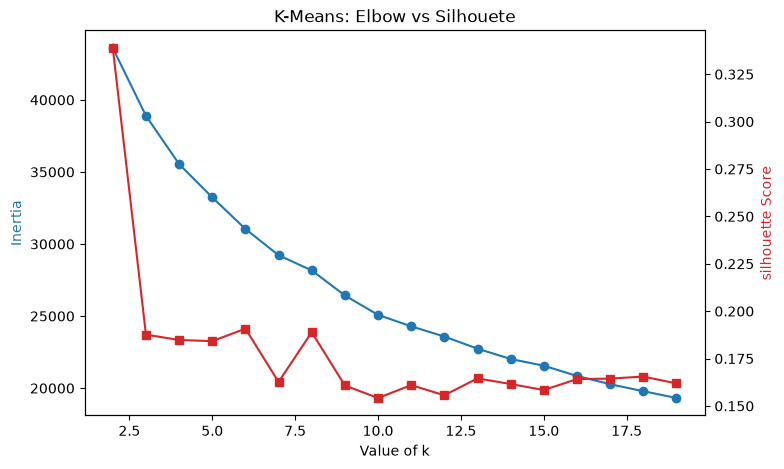

,k,inertia,silhouette
0,2,43600.438842,0.338837
1,3,38896.420388,0.187630
2,4,35546.455036,0.184802
3,5,33235.966368,0.184186
4,6,31044.834419,0.190775
5,7,29221.696898,0.162666
6,8,28170.602782,0.188918
7,9,26430.447898,0.160805
8,10,25083.603161,0.154200
9,11,24290.407049,0.160997


In [15]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 20)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    km = KMeans(n_clusters = k, n_init = 10)
    labels = km.fit_predict(retail_scaled)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(retail_scaled, labels))

# Implement a dataframe showing results as numerical values:
results_df = pd.DataFrame({
    'k' : list(k_range),
    'inertia' : inertias,
    'silhouette' : silhouette_scores
}
)

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

results_df

**Analysis**

at this point k=2 is continously being a dominant value across two different rounds of outlier removal. It might be a suitable choice for the value of K. To confirm this a new strategy will be used. Instead of trying to diagnose if there is errors within the data, the reason for the split is what will be searched for. 

Removing the negative 'total_item_count' values only led to minimal positive changes within the results for both tests. Silhouette scores still sits firmly at k = 2 sugesting this split is a reflection of genuiene customer behaviour rather than distortion caused by extreme outlying values. When comparing with the previous tests, there is some improvement in the mid ranges for k. For example k = 7 sees a modest rise from 0.170 -> 0.191 sugesting that the invalid negative values were causing some noise within the clusters. After this point however, results remain virtually unchanged. Past k = 8 both tests reflect low flat scores in the ranges 0.15 - 0.17.Inertia also displays no meaningful changes either. Both tests visually show a smooth curved line with no clear elbow point. 

These results confirm that k = 2 is a very dominant split within the data. Whilst k = 2 is statistically the strongest result, a k value of 7 will also be inspected as it is the second highest silhouette result - under the logic that more clusters may reveal more business-actionable level insights. On the other hand, inertia provided no meaningful indication of a suitable k value as neither tests displayed an identifable elbow.  

### 2.3 - Running Kmeans Algorithm Tests
This section showcases the tests and results for both values of k (2, 7) starting with k = 2.

In [16]:
# Initilise a K-means model using 2 clusters (dominant split test)
Kmeans_two = KMeans(n_clusters=2, random_state=42, n_init=10)
# Fit the model to the scaled retail data - assinging customers a value (0,1)
labels2 = Kmeans_two.fit_predict(retail_scaled)

# Add the cluster labels into the dataset corresponding each customer with their value: 
retail_features['cluster'] = labels2
print("=== KMEANS ALGORITHM RESULTS (K = 2) ===")
# Groupby averages the customers within each cluster value for each feature and returns the mean. 
retail_features.groupby('cluster')[feature_cols].mean()

=== KMEANS ALGORITHM RESULTS (K = 2) ===


,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
cluster,,,,,,,,,,
0,822.633877,255.075132,3.609856,485.409081,0.097953,47.479664,12.592425,2.564235,0.117639,0.288358
1,4953.323155,395.061605,16.535343,2937.314969,0.178758,195.692308,12.537422,2.610187,0.118063,0.321206


**k = 2 Cluster Results**

The results from the KMeans test above displays clear split that is consitant with the silhouette score results. Cluster 1 shows much higher values across features in comparison to cluster 0. For example: 

- total_spend = ~ 6 times higher in cluster 1 (£4,953 -> £823)
- visit_frequency = ~ 4 times higher in cluster 1 (16.5 vs 3.6)
- total_item_count = ~ 6 times higher in cluster 1 (2937 vs 485)
- unique_products = ~ 4 times higher in cluster 1 (195 vs 47)

Other features such as 'discount_rate' and 'loyalty_member' displayed minimal difference between the two segements. This is an indication that these features are not meaningfully contributing the the split. 

These results show that when k = 2 the split is being entirely by engagement based metrics alone (like spend, frequency, product variety) and other metrics suchs as discounts and loyalty contribute little to clusters. More specifically, in this example the split is represented by low-engagment occasional custoewrs (cluster 0) followed by high-engagement, frequently visiting customers (cluster 1). 

The next test will be deploying a Kmeans algorithm with a k value of 7. 

In [17]:
# Initilise a K-means model using 7 clusters (second highest silhouette score)
Kmeans_seven = KMeans(n_clusters=7, n_init=10)
# Fit the model to the scaled retail data - assinging customers a value (0,1)
labels7 = Kmeans_seven.fit_predict(retail_scaled)
# Add the cluster labels into the dataset corresponding each customer with their value: 
retail_features['cluster'] = labels7
print("=== KMEANS ALGORITHM RESULTS (K = 7) ===")
# Groupby averages the customers within each cluster value for each feature and returns the mean. 
retail_features.groupby('cluster')[feature_cols].mean()

=== KMEANS ALGORITHM RESULTS (K = 7) ===


,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
cluster,,,,,,,,,,
0,3248.965676,317.769727,11.640643,1955.091848,0.155499,156.532721,12.529277,2.826636,0.118051,0.246843
1,323.481187,196.026409,1.812785,170.392694,0.012545,11.767123,12.360731,2.337900,0.344463,0.191781
2,933.504576,190.295565,5.201342,544.098434,0.389416,46.248322,12.288591,2.303132,0.114092,0.157718
3,3146.036280,1485.126692,2.224299,1643.345794,0.037461,69.644860,12.476636,2.242991,0.112209,0.364486
4,828.280302,266.582405,3.386219,487.993654,0.050725,48.426111,12.771532,2.600181,0.110909,1.000000
5,608.692582,243.925209,2.656130,361.481801,0.009714,39.688697,12.677203,2.623084,0.098867,0.000000
6,7129.855541,346.443933,24.394495,4238.223242,0.185290,259.617737,12.477064,2.474006,0.119924,0.333333


**k = 7 Cluster Results**
Increasing the value of k from 2 to 7 reveals richer and more descriptive consumer segments. Rather than a split based on engagment metrics seen in k = 2, this split provies seven distinct and interpretable customer segments. There are various different characteristics seen with the results above, for example: 

- **Cluster 0:** With the second highest total_spend and total_visit values, this cluster could represent regular, engaged customers. 

- **Cluster 1:** The lowest spend value paired with the fewest unique products but the highest discount rate value, this cluster represents small discount driven purchases. 

- **Cluster 2:** Mid range spend, lowest average transaction value and highest cancellation rate, this cluster indicates a group of frequent low value repeat customers. 

- **Cluster 3:** This cluster has a specific behaviour. With a moderate mid value spend paired with the highest average transaction and a low visit value. This cluster points to a group of high value infreuqent one-off purchases. 

- **Cluster 4:** Cluster 4 has a modest spend value, being only the 3rd lowest however, the key with this cluster is loyalty having a value of 1. This cluster reflects the behaviours of membership customers.

- **Cluster 5:** Low spend and low values for the rest of the features. Most notably loyalty has a value of 0, indicating this cluster represents non-members - most likely this cluster 

- **Cluster 6:** highest spend followed by most visits and most items bought as well as most amount of unique products. This cluster represents the business' core customers. 

Increasing the value of K within this algorithm clearly returns a much more profficient result in comparison to the k = 2 split. Here we can see multiple different cluster behaviours from core customers to infrequent large transactions to customers who prefer to shop with discounts. 

An interesting point to investigate is the effect the binary features such as 'cancellation_rate'


using 7 clusters produced more granular segements.
EXPAND

both k = 2 and k = 7 produce intesting and meaningful segments but with k = 7 providing richer results. and interesting aspect to investigate is the within cluster 4 and its value of 1.000 in loyalty member. similar to discount_rate, are these features influencing the others. The next code block will remove loyalty_member and dicount_rate and evaluate if there is a difference in results. 

In [25]:
# Remove the two features from the dataset: 
binary_removal_features = retail_features.drop(columns=['loyalty_member', 'discount_rate'])

# Create a new list: 
removed_feature_cols = [col for col in feature_cols if col not in ['loyalty_member', 'discount_rate']]

# Refit Standard Scalar: 
binary_removed_scaled = scaler.fit_transform(binary_removal_features[removed_feature_cols])

# Run K means again using new dataframe:
Kmeans_seven_tuned = KMeans(n_clusters=7, n_init=10)
labels2 = Kmeans_seven_tuned.fit_predict(binary_removed_scaled)

retail_features['cluster'] = labels2
retail_features.groupby('cluster')[removed_feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week
cluster,,,,,,,,
0,933.997553,190.540759,5.235818,552.226919,0.393220,45.765295,12.300334,2.246941
1,610.867032,238.832741,2.676866,359.520896,0.017341,41.109701,14.664925,1.755970
2,3220.469642,1490.978068,2.283019,1695.726415,0.040173,70.622642,12.575472,2.160377
3,732.125599,246.060360,3.185144,425.441242,0.032738,54.388027,12.783814,5.337029
4,685.324338,260.601564,2.820384,405.456976,0.020284,33.801170,10.383459,1.664160
5,7239.658400,344.610691,24.809836,4302.081967,0.183512,267.586885,12.534426,2.521311
6,3371.482284,322.110388,12.011628,2025.838372,0.158574,155.867442,12.503488,2.616279


moving forward, use the 8-feature KMeans test with k at 7. This is to ensure binary features dont disproportionately influence Kmeans model ( as it is Euclidean Distance model) and k = 7 as it provides more interpretable, distinct business segments as opposed to k =2. 

As a final test, a David-Bouldin test will be ran in order to help reinforce the decion. 

In [19]:
# Initlise a new list to store results: 
db_scores = []

# Initilise loop and append results to the list: 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(retail_scaled)
    db_scores.append(davies_bouldin_score(retail_scaled, labels))

# Create a dataframe, displaying values of K and DB. 
db_results = pd.DataFrame({'k': list(k_range), 'davies_bouldin': db_scores})
# Print the dataframe: 
db_results

,k,davies_bouldin
0,2,1.431359
1,3,1.791541
2,4,1.728913
3,5,1.730113
4,6,1.606372
5,7,1.524119
6,8,1.509894
7,9,1.443769
8,10,1.534803
9,11,1.565778


results here reinforces the tests that were preveiously ran. Both silhouette and davies-Bouldin have the best scores at k=2. This means that mathimatically k=2 is the strongest split for the KMeans test, however k=7 offers more actionable insights. The trade off here is what is the best 'mathematical' answer and the most useful one. 

DBSCAN

finds clusters based on density 

has two hyper parameters: EPS - the maximum distance between two points for them to be considered neighbours. If too small points can be labelled as noise and become isolated. If the distance is too large however and everything comes one large cluster. EPS gives an indication into the best suited value. 

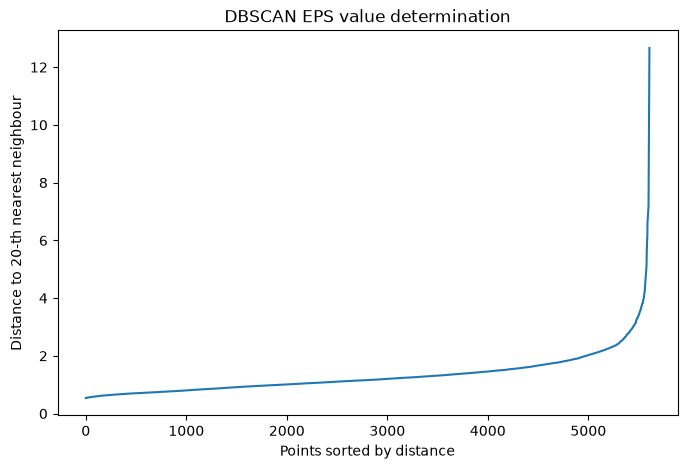

In [20]:
# Initilise variable twice the size og feature_cols
min_samples = 2 * len(feature_cols)

# Initilise variable - 
neighbors = NearestNeighbors(n_neighbors = min_samples)
#
neighbors_fit = neighbors.fit(retail_scaled)
#
distances, indicies = neighbors_fit.kneighbors(retail_scaled)

#
k_distances = np.sort(distances[:, -1])

# Initilise and display Plot: 
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}-th nearest neighbour')
plt.title('DBSCAN EPS value determination')
plt.show()

most points will be close together, hence the flat line, however points that sit further out will start to drag distance out as well, which is where a curve will be formed. The point at which the knee starts represents the distance value that bests suits the data. Here we can see that the curve happens between 2~4. Below a closer inspection will be carried out in order to produce a more concrete answer. 

In [21]:
# Look at the actual distance values around where the bend happens
for position in [4000, 4500, 5000, 5200, 5400,5500, 5600, 5607]:
    print(f"Position {position}: {k_distances[position]:.4f}")

Position 4000: 1.4564
Position 4500: 1.6616
Position 5000: 2.0205
Position 5200: 2.2527
Position 5400: 2.7903
Position 5500: 3.4023
Position 5600: 7.7853
Position 5607: 12.3626


position 5500 shows the first point where values start to climb with an EPS value of 3.4. The code block below will test this value with DBSCAN which should provide some evidence of usable clustering or not. 

In [22]:
# Set the EPS value: 
eps_value = 3.4 
# min_samples has already been initilised. 

# Initilise DBSCAN: 
db = DBSCAN(eps = eps_value, min_samples = min_samples)

# Fit the model with the data: 
db_labels = db.fit_predict(retail_scaled)

# Init variable to count clusters: 
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
# Init variable to count noise: 
n_noise = list(db_labels).count(-1)

# Print results: 
print(f"Clusters Found: {n_clusters}")
print(f"Noise Points: {n_noise}")

Clusters Found: 1
Noise Points: 41


The results here confirm that eps of 3.4 is too high. DBSCAN reutrned one cluster and 41 noise points from 5600 customers, meaning nearly every customer was grouped together into one segement which is not suitable for finding meaningful sub groups. The next test will be to test with a lower eps and examine the results.

In [23]:

# Create a list for eps values recorded between customer 4000 and 5200
eps_values = [1.0, 1.4, 1.6, 2.0, 2.25]

for value in eps_values:
    # re-initilise DBSCAN: 
    db = DBSCAN(eps = value, min_samples = min_samples)
    # Fit the model with the data: 
    db_labels = db.fit_predict(retail_scaled)
    # Init variable to count clusters: 
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    # Init variable to count noise: 
    n_noise = list(db_labels).count(-1)
    # Print results: 
    print(f"eps={value} -> Clusters Found: {n_clusters}, Noise Points: {n_noise}")

eps=1.0 -> Clusters Found: 5, Noise Points: 2599
eps=1.4 -> Clusters Found: 2, Noise Points: 942
eps=1.6 -> Clusters Found: 2, Noise Points: 601
eps=2.0 -> Clusters Found: 2, Noise Points: 267
eps=2.25 -> Clusters Found: 1, Noise Points: 189


Why is DBSCAN finding only 2 segments? its does so naturally unlike KMeans which is asked to do it. shows that DBSCAN is not well suited for this type of ML work. 

In [24]:
db = DBSCAN(eps=2.0, min_samples=min_samples)
db_labels = db.fit_predict(retail_scaled)

retail_features['dbscan_cluster'] = db_labels
retail_features.groupby('dbscan_cluster')[feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
dbscan_cluster,,,,,,,,,,
-1,5991.719483,674.323875,18.314607,3663.640449,0.143644,215.955056,12.767790,2.677903,0.167159,0.434457
0,1309.589208,254.625097,5.224206,766.978997,0.111342,65.682856,12.566290,2.568391,0.115061,0.000000
1,1304.541492,271.018874,5.148728,770.892368,0.107437,65.915199,12.592303,2.562948,0.115687,1.000000
